# Experiment 6 — Linear probing and variance partitioning

Reproduction guidebook §9.

> **Questions.** (a) Is confidence information decodable from PANL at *earlier* layers than
> from CC? (b) Do PANL representations merely summarize token log-probabilities, or reflect a
> distinct computation?
> **Key result.** (a) Yes. (b) A distinct computation — PANL activations at L40 explain **38%
> unique variance** beyond **all six** log-probability baselines combined, which themselves
> explain only **10%**.

Causal interventions test sufficiency and necessity; probing reveals **where** information
first becomes decodable and **what kind** of information it is.

In [1]:
import pathlib
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents] if (p / "vconf").is_dir())
sys.path.insert(0, str(ROOT))

from vconf import notebook as nb

from vconf import exp0_behavioral as E0
from vconf import exp6_probing as E6
from vconf import metrics as M
from vconf import plotting

cfg = nb.run_config("gemma-categorical")
print(nb.describe(cfg))
print("the six log-probability baselines (§9.2):", E6.BASELINE_NAMES)

profile          : reduced
model            : Qwen/Qwen2.5-7B-Instruct (28 layers)
prompt / dataset : categorical / triviaqa
layer sweep      : (0, 5, 11, 16, 22, 27)
trial counts     : {'steering': 24, 'patching': 24, 'noising': 32, 'swap': 24, 'attention': 24}
activation set   : 300   calibration set: 40
chat template    : True   attention impl: None
NOTE             : reduced profile — procedures, prompts, positions and
                   metrics follow the manual exactly, but the model and the
                   sample sizes are smaller than the paper's, so the numbers
                   here are not expected to match its reported values.
the six log-probability baselines (§9.2): ('mean', 'min', 'max', 'var', 'first', 'last')


In [2]:
loaded = nb.open_model(cfg)
trials, rendered = nb.build_trials(loaded, cfg)
trials = nb.graded(trials)
# §9.1 probes the activation-collection set, which §2.3.4 keeps disjoint from
# every experiment's test trials.
(trials, rendered), _ = nb.split_activation_holdout(trials, rendered, cfg)
store = nb.activation_store(loaded, cfg, rendered, trials=trials)
print(len(trials), "activation-collection trials |", nb.grader_note())

Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

300 activation-collection trials | OPENAI_API_KEY is not set, so correctness labels come from the documented fallback (normalised alias matching), not the manual's gpt-4o-mini grader (§2.3.1) — accuracy/ECE/AUROC here are approximate for that reason


## Probing (§9.1)

Two probe targets per (layer, position), both 5-fold cross-validated with all activations
z-scored before fitting:

| Target | Model | Metric |
|---|---|---|
| answer correctness (binary) | L2-regularised logistic regression | AUROC |
| verbal confidence magnitude (class midpoints) | Ridge regression (α = 1.0) | R² |

Positions: PANL, PANL+1, CC, FCC, the answer-colon AC, and the control **QTT** (third
question token), which must be null.

In [3]:
positions = ("PANL", "PANL+1", "CC", "FCC", "AC", "QTT")
probing = E6.layerwise_probing(store, trials, positions=positions, layers=cfg.layers)
probing.pivot(index="layer", columns="position", values="confidence_r2").round(3)

position,AC,CC,FCC,PANL,PANL+1,QTT
layer,,,,,,
0,-1.031,-0.408,-0.504,-0.058,-0.114,-0.885
5,-0.521,-0.048,-0.067,0.159,-0.080,-1.385
11,-0.599,-0.103,-0.047,0.262,-0.261,-2.588
16,-0.271,0.318,0.157,0.608,0.102,-2.111
22,0.015,0.786,0.520,0.528,0.299,-1.840
27,-0.067,0.797,0.605,0.467,0.245,-2.436


In [4]:
probing.pivot(index="layer", columns="position", values="correctness_auroc").round(3)

position,AC,CC,FCC,PANL,PANL+1,QTT
layer,,,,,,
0,0.656,0.689,0.711,0.703,0.656,0.655
5,0.787,0.808,0.822,0.804,0.784,0.653
11,0.797,0.841,0.820,0.834,0.797,0.666
16,0.825,0.886,0.851,0.884,0.802,0.629
22,0.818,0.858,0.857,0.867,0.848,0.648
27,0.788,0.820,0.862,0.865,0.843,0.569


## Decodability against layer (§9.5)

Reference horizontal lines: verbal confidence itself predicts correctness at AUROC 0.71, and
the mean answer log-probability at AUROC 0.75 — the calibration gap that makes the
second-order question non-trivial.

PosixPath('/scratch/qi/project/results/figures/exp6-probing-qwen-categorical-triviaqa-reduced.png')

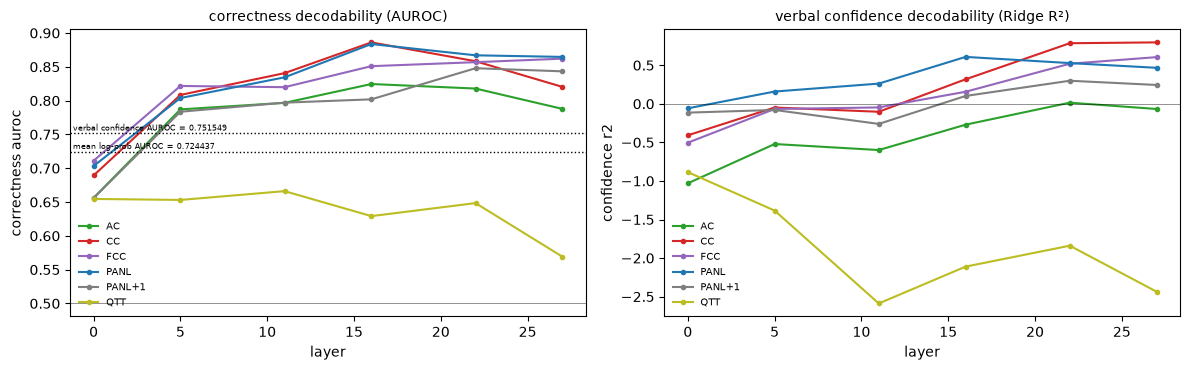

In [5]:
stats = E0.calibration(trials)
reference = {
    "verbal confidence AUROC": stats["auroc"],
    "mean log-prob AUROC": E0.logprob_correctness_auroc(trials),
}
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
plotting.probing_curves(probing, "correctness_auroc", ax=axes[0], reference=reference,
                        title="correctness decodability (AUROC)")
axes[0].axhline(0.5, color="k", lw=0.6, alpha=0.5)
plotting.probing_curves(probing, "confidence_r2", ax=axes[1],
                        title="verbal confidence decodability (Ridge R²)")
axes[1].axhline(0.0, color="k", lw=0.6, alpha=0.5)
fig.tight_layout()
plotting.save_figure(fig, f"exp6-probing-{cfg.name}")

In [6]:
rows = []
for position in positions:
    group = probing[probing["position"] == position]
    paper = E6.PAPER_TARGETS["probing"].get(position, {})
    rows.append({
        "position": position,
        "peak AUROC": round(float(group["correctness_auroc"].max()), 3),
        "paper AUROC": paper.get("auroc"),
        "AUROC onset layer (>0.6)": int(group[group["correctness_auroc"] > 0.6]["layer"].min())
            if (group["correctness_auroc"] > 0.6).any() else None,
        "peak R²": round(float(group["confidence_r2"].max()), 3),
        "paper R²": paper.get("r2"),
        "R² peak layer": int(group.loc[group["confidence_r2"].idxmax(), "layer"]),
    })
pd.DataFrame(rows)

,position,peak AUROC,paper AUROC,AUROC onset layer (>0.6),peak R²,paper R²,R² peak layer
0,PANL,0.884,"(0.8, 0.83)",0,0.608,0.45,16
1,PANL+1,0.848,0.8,0,0.299,"(0.35, 0.45)",22
2,CC,0.886,"(0.8, 0.83)",0,0.797,0.8,27
3,FCC,0.862,0.8,0,0.605,0.45,27
4,AC,0.825,None,0,0.015,0.2,22
5,QTT,0.666,0.5,0,-0.885,0.0,0


## Log-probability baselines (§9.2, §9.5)

Six summaries of the per-token log-probabilities over the answer span: the length-normalised
mean, the minimum, the maximum, the variance, and the first and last answer tokens.

| Baseline | paper R²_CV |
|---|---|
| min | 0.101 |
| mean (length-normalised) | 0.084 |
| first | 0.070 |
| variance | 0.051 |
| last | 0.039 |
| max | 0.025 |
| **all six combined** | **0.100** |

The six combined barely exceed the best single one — they carry substantially overlapping
linear information.

In [7]:
baselines = E6.baseline_only_r2(trials)
paper_r2 = E6.PAPER_TARGETS["baseline_r2"]
baselines["paper r2_cv"] = [paper_r2.get(name, paper_r2["all_six"]) for name in baselines["baseline"]]
baselines.round(4)

,baseline,r2_cv,pearson_r,paper r2_cv
0,mean,0.0833,0.3167,0.084
1,min,0.1799,0.4444,0.101
2,max,0.0102,0.1600,0.025
3,var,0.0097,-0.2453,0.051
4,first,0.1036,0.3580,0.070
5,last,0.0446,0.2445,0.039
6,all six combined,0.1566,NaN,0.100


## Variance partitioning (§9.3)

For each (layer, position), three cross-validated Ridge regressions predicting the verbal
confidence midpoint — activations alone, log-prob baselines alone, and both concatenated —
give

$$R^2_{\text{unique}} = \max\!\left(0,\; R^2_{\text{both}} - R^2_{\text{base}}\right).$$

Run against **all six baselines combined**, which is the most conservative test: it credits
the baselines with every redundant linear signal they share.

In [8]:
partition = E6.layerwise_variance_partition(
    store, trials, positions=("PANL", "PANL+1", "CC", "AC"), layers=cfg.layers, baseline="all"
)
partition.round(3)

,layer,position,baseline,r2_activations,r2_baselines,r2_both,r2_unique
0,0,PANL,all,-0.058,0.157,-0.009,0.000
1,0,PANL+1,all,-0.114,0.157,-0.093,0.000
2,0,CC,all,-0.408,0.157,-0.263,0.000
3,0,AC,all,-1.031,0.157,-0.702,0.000
4,5,PANL,all,0.159,0.157,0.170,0.013
5,5,PANL+1,all,-0.080,0.157,-0.063,0.000
6,5,CC,all,-0.048,0.157,-0.022,0.000
7,5,AC,all,-0.521,0.157,-0.466,0.000
8,11,PANL,all,0.262,0.157,0.269,0.113
9,11,PANL+1,all,-0.261,0.157,-0.281,0.000


PosixPath('/scratch/qi/project/results/figures/exp6-variance-partition-qwen-categorical-triviaqa-reduced.png')

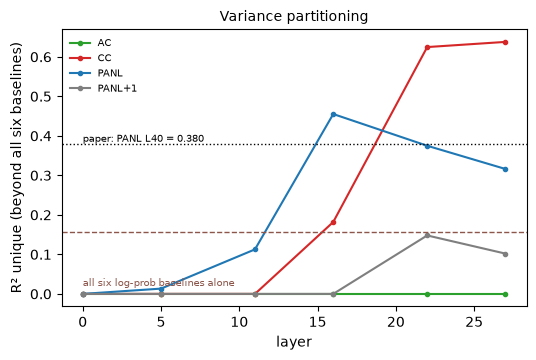

In [9]:
fig, ax = plt.subplots(figsize=(6, 3.6))
for position, group in partition.groupby("position"):
    group = group.sort_values("layer")
    ax.plot(group["layer"], group["r2_unique"], marker="o", markersize=3,
            color=plotting.POSITION_COLORS.get(str(position)), label=str(position))
ax.axhline(E6.PAPER_TARGETS["unique_r2_panl_l40"], color="k", ls=":", lw=1)
ax.annotate("paper: PANL L40 = 0.380", (cfg.layers[0], 0.385), fontsize=7)
ax.axhline(float(baselines[baselines["baseline"] == "all six combined"]["r2_cv"].iloc[0]),
           color="#8c564b", ls="--", lw=1)
ax.annotate("all six log-prob baselines alone", (cfg.layers[0], 0.02), fontsize=7,
            color="#8c564b")
ax.set_xlabel("layer")
ax.set_ylabel("R² unique (beyond all six baselines)")
ax.set_title("Variance partitioning", fontsize=10)
ax.legend(fontsize=7, frameon=False)
plotting.save_figure(fig, f"exp6-variance-partition-{cfg.name}")

## Auxiliary correlation diagnostics (§9.4)

| Quantity | paper |
|---|---|
| length-normalised mean log-prob → verbal confidence (cross-run, Phase 1) | r = 0.29, R²_CV = 0.084 |
| the same, within-run (Phase 0) | r = 0.23, R²_CV = 0.049 |
| all six baselines combined | r = 0.32, R²_CV = 0.100 |
| Phase-0 vs Phase-1 confidence consistency | r = 0.63, R²_CV = 0.40 |

In [10]:
diagnostics = E6.correlation_diagnostics(trials)
paper = E6.PAPER_TARGETS["correlations"]
pd.DataFrame([
    {"quantity": "log-prob vs Phase-1 confidence (cross-run)",
     "reproduction r": round(diagnostics["logprob_vs_phase1_r"], 3), "paper r": paper["cross_run_r"]},
    {"quantity": "log-prob vs Phase-0 confidence (within-run)",
     "reproduction r": round(diagnostics["logprob_vs_phase0_r"], 3), "paper r": paper["within_run_r"]},
    {"quantity": "Phase-0 vs Phase-1 confidence consistency",
     "reproduction r": round(diagnostics["phase0_vs_phase1_r"], 3),
     "paper r": paper["phase0_phase1_r"]},
])

,quantity,reproduction r,paper r
0,log-prob vs Phase-1 confidence (cross-run),0.317,0.29
1,log-prob vs Phase-0 confidence (within-run),0.141,0.23
2,Phase-0 vs Phase-1 confidence consistency,0.385,0.63


## Validation against §9.5–9.6

In [11]:
panl = partition[partition["position"] == "PANL"]
cc = partition[partition["position"] == "CC"]
best_panl = float(panl["r2_unique"].max())
combined_baseline = float(baselines[baselines["baseline"] == "all six combined"]["r2_cv"].iloc[0])
best_single = float(baselines[baselines["baseline"] != "all six combined"]["r2_cv"].max())

panl_probe = probing[probing["position"] == "PANL"]
cc_probe = probing[probing["position"] == "CC"]
qtt_probe = probing[probing["position"] == "QTT"]

def onset(group, column, threshold):
    hit = group[group[column] > threshold]
    return int(hit["layer"].min()) if len(hit) else 10**6

checks = {
    "Q8 PANL explains unique variance beyond all six baselines": best_panl > 0,
    "Q8 that unique variance exceeds the baselines' own R²": best_panl > combined_baseline,
    "the six baselines barely beat the best single one":
        combined_baseline <= best_single + 0.05,
    "Q3 confidence is decodable from PANL earlier than from CC":
        onset(panl_probe, "confidence_r2", 0.1) <= onset(cc_probe, "confidence_r2", 0.1),
    "the QTT control is near chance for correctness":
        float(qtt_probe["correctness_auroc"].max()) < 0.7,
    "the QTT control explains little confidence variance":
        float(qtt_probe["confidence_r2"].max()) < 0.2,
}
for name, ok in checks.items():
    print(f"{'PASS' if ok else 'FAIL'}  {name}")
print(f"\nbest PANL R²_unique = {best_panl:.3f} (paper 0.380) | "
      f"all six baselines R²_CV = {combined_baseline:.3f} (paper 0.100)")

PASS  Q8 PANL explains unique variance beyond all six baselines
PASS  Q8 that unique variance exceeds the baselines' own R²
PASS  the six baselines barely beat the best single one
PASS  Q3 confidence is decodable from PANL earlier than from CC
PASS  the QTT control is near chance for correctness
PASS  the QTT control explains little confidence variance

best PANL R²_unique = 0.455 (paper 0.380) | all six baselines R²_CV = 0.157 (paper 0.100)


**Interpretation (§9.6).**

1. **Temporal precedence, non-causally.** Confidence is decodable from PANL at earlier layers
   than from CC — an independent confirmation of the cached-retrieval ordering by a method
   that makes no causal intervention at all.
2. **Not a log-prob readout.** PANL activations explain unique variance on top of the most
   conservative possible log-probability baseline. Verbal confidence is not reducible to
   token-level probability signals, whether measured as mean, extremes, variability or
   position-specific values. This is the core evidence for the **second-order** account.
3. **Probing ≠ causal relevance.** Confidence information is decodable *throughout* the model,
   including at sites where steering and patching have no effect (PANL+1, FCC). Probing alone
   would not have established the paper's claims — the combination with causal interventions
   is what does.